# Model Training v8 — main results for the camera-ready paper

Same models, hyperparameters, preprocessing and speaker-grouped CV as `model_training_v7.ipynb`
(which produced the submitted 0.891 / 0.637). What changed:

| Change | Why |
|---|---|
| Per-fold scores kept → **mean ± SD and 95% CI** for every model | Reviewer g1YR |
| Every setting is run **with and without age + sex**, plus an **age + sex only** baseline | g1YR: metadata confound. Ablation v2 showed age alone reaches 0.83 |
| **Age × sex matched** settings (nearest neighbour, same sex, ±2 years) | g1YR: demographic matching |
| Feature set restricted to the families described in the paper (MFDFA, eGeMAPS, NeuroKit2) | v7 also fed `audio_num_samples` (recording length) and constant bookkeeping columns to the models |
| **All 107 described features are used**: no MFCC/formant exclusion, no collinearity filter | Neither step is described in the paper; together they left 52 features (only 4 of 12 MFDFA). Set `STRICT_FEATURES = False`, `DROP_MFCC_FORMANTS = True`, `USE_COLLINEARITY_FILTER = True` to reproduce v7 |
| **Per-disease detection redone** (section 13): 5-fold CV, with and without age + sex, and age-matched | The old per-disease notebook ran 2-fold CV for every disease (a faulty split check) and always included age + sex |
| Feature tables are read **directly from the cached CSVs** | The WAVs are deleted; v7's loader could trigger a rebuild |
| Labels are NFC-normalised before mapping | v7 handled this by listing *Phonationsknötchen* twice; this makes it explicit |
| Results exported to `results/main_v8/` | Tables for the paper |

**Expected runtime:** roughly 8–10× v7 (four binary settings × 4 models, three disease-group settings × 3 models, plus feature importances).

## 1 — Setup

In [15]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

## 2 — Configuration (v7 values unless marked NEW)

In [16]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SELECTED_TOKEN = 'a_n'
MIN_SAMPLES_PER_CLASS = 50
BALANCE_HEALTHY = True
EXCLUDE_MIXED_BINARY_SPEAKERS = True

N_SPLITS = 5
THRESHOLD_GRID = np.linspace(0.35, 0.65, 11)
BINARY_THRESHOLD_OBJECTIVE = 'accuracy'
COLLINEARITY_THRESHOLD = 0.85

STRICT_FEATURES = True        # NEW: only MFDFA / eGeMAPS / NeuroKit2 (+ age, sex). False = exact v7 columns
MATCH_CALIPER_YEARS = 2.0     # NEW: nearest-neighbour age matching, same sex, within ± this many years
DROP_MFCC_FORMANTS = False    # NEW: v7 dropped 34 MFCC / formant descriptors (True = v7 behaviour)
USE_COLLINEARITY_FILTER = False  # NEW: v7 dropped features with |r| > 0.85 (True = v7 behaviour)
MIN_DISEASE_SAMPLES = 10      # per-disease: skip diseases with fewer samples (as in the old notebook)
MIN_MATCHED_PAIRS = 20        # per-disease: report the matched result only with at least this many pairs

DISEASE_GROUP_MAP = {
    'Morbus Parkinson': 'Neurological',
    'Rekurrensparese': 'Neurological',
    'Spasmodische Dysphonie': 'Neurological',
    'Phonationsknötchen': 'Structural',
    'Stimmlippenpolyp': 'Structural',
    'Laryngitis': 'Structural',
    # v7's code also maps three dysphonias to a 'Functional' group, but those lines were added AFTER
    # its last run: the saved v7 output (and the paper's 0.637) used only Neurological vs Structural.
    # They are left out here to match the paper's two-group task (956 samples, as in v7's output).
}

ROOT = Path('..')
FEAT_DIR = ROOT / 'data' / 'processed' / 'features'
MANIFEST_PATH = ROOT / 'data' / 'processed' / 'manifests' / 'dataset_manifest.csv'
OUT_DIR = ROOT / 'results' / 'main_v8'
OUT_DIR.mkdir(parents=True, exist_ok=True)

nfc = lambda s: unicodedata.normalize('NFC', s) if isinstance(s, str) else s
DISEASE_GROUP_MAP = {nfc(k): v for k, v in DISEASE_GROUP_MAP.items()}

## 3 — Load cached feature tables (read-only)

In [17]:
def _read(name):
    return pd.read_csv(FEAT_DIR / f'{name}.csv').drop_duplicates(subset=['sample_key'])

df_all = (_read('sample_core')
          .merge(_read('multifractal_features'), on='sample_key', how='left')
          .merge(_read('opensmile_features'), on='sample_key', how='left')
          .merge(_read('neurokit2_features'), on='sample_key', how='left'))

manifest = pd.read_csv(MANIFEST_PATH, usecols=['sample_key', 'birth_date', 'recording_date'], low_memory=False)
df_all = df_all.merge(manifest.drop_duplicates(subset=['sample_key']), on='sample_key', how='left').copy()
bd = pd.to_datetime(df_all['birth_date'], errors='coerce')
rd = pd.to_datetime(df_all['recording_date'], errors='coerce')
df_all['age'] = ((rd - bd).dt.days / 365.25).round(1)
df_all = df_all.drop(columns=['birth_date', 'recording_date'])

df_all = df_all[df_all['feature_status'].isin(['ok', 'partial_failure'])
                & df_all['mf_status'].eq('ok') & df_all['opensmile_status'].eq('ok') & df_all['nk_status'].eq('ok')].copy()
df_all['pathology_de'] = df_all['pathology_de'].map(nfc)
print(f'Loaded {len(df_all)} a_n samples, {df_all.speaker_id.nunique()} speakers, age missing: {df_all.age.isna().sum()}')

Loaded 1656 a_n samples, 1355 speakers, age missing: 0


## 4 — Targets and filters (v7 protocol, logged)

In [18]:
protocol = []
def log(step, before, after, detail=''):
    protocol.append({'step': step, 'samples_before': before, 'samples_after': after, 'detail': detail})

def drop_mixed(x):
    g = x.groupby(x['speaker_id'].astype(str))['is_healthy'].nunique()
    mixed = set(g[g > 1].index)
    return x[~x['speaker_id'].astype(str).isin(mixed)].copy(), len(mixed)

# Branch A (all pathologies, used only for the robustness matching): mixed speakers removed over everything
d_allp, _ = drop_mixed(df_all)
healthy_pool_all = d_allp[d_allp['is_healthy'].astype(bool)].copy()
all_patho_pool = d_allp[~d_allp['is_healthy'].astype(bool)].copy()

# Branch B (main set), in v7's order: map -> drop unmapped -> drop mixed speakers -> drop small classes -> balance
d = df_all.copy()
log('Start: a_n recordings with all feature families extracted', len(d), len(d))
mapped = d['pathology_de'].map(DISEASE_GROUP_MAP)
unmapped = mapped.isna() & ~d['is_healthy'].astype(bool)
n0 = len(d)
dropped = d.loc[unmapped, 'pathology_de'].value_counts().to_dict()
d = d[~unmapped].copy()
d['target_label'] = np.where(d['is_healthy'].astype(bool), 'healthy', d['pathology_de'].map(DISEASE_GROUP_MAP))
log('Drop pathologies outside the two disease groups', n0, len(d), str(dropped))

if EXCLUDE_MIXED_BINARY_SPEAKERS:
    n0 = len(d)
    d, n_mixed = drop_mixed(d)
    log('Drop speakers with both healthy and pathological recordings', n0, len(d), f'{n_mixed} speakers')

n0 = len(d)
vc = d['target_label'].value_counts()
small = vc[vc < MIN_SAMPLES_PER_CLASS].index.tolist()
d = d[~d['target_label'].isin(small)].copy()
log(f'Drop classes with < {MIN_SAMPLES_PER_CLASS} samples', n0, len(d), str(small) if small else 'none')

healthy_pool = d[d['is_healthy'].astype(bool)].copy()   # full healthy pool, before downsampling
patho6_pool = d[~d['is_healthy'].astype(bool)].copy()

n0 = len(d)
if BALANCE_HEALTHY:
    hm = d['is_healthy'].astype(bool)
    n_patho = int((~hm).sum())
    if hm.sum() > n_patho:
        d = d.drop(d[hm].sample(n=int(hm.sum()) - n_patho, random_state=RANDOM_SEED).index).copy()
log('Randomly downsample healthy to the pathological count (seed 42)', n0, len(d))

df = d
protocol_df = pd.DataFrame(protocol)
display(protocol_df)
display(df.groupby(['target_label', 'pathology_de']).agg(samples=('sample_key', 'size'), speakers=('speaker_id', 'nunique')))
print(f'Main set: {len(df)} samples, {df.speaker_id.nunique()} speakers  (v7: 956 samples, 820 speakers)')

,step,samples_before,samples_after,detail
0,Start: a_n recordings with all feature familie...,1656,1656,
1,Drop pathologies outside the two disease groups,1656,1167,"{'Hyperfunktionelle Dysphonie': 213, 'Funktion..."
2,Drop speakers with both healthy and pathologic...,1167,1163,2 speakers
3,Drop classes with < 50 samples,1163,1163,none
4,Randomly downsample healthy to the pathologica...,1163,956,


samples  speakers
target_label pathology_de                             
Neurological Morbus Parkinson              1         1
             Rekurrensparese             212       155
             Spasmodische Dysphonie       64        12
Structural   Laryngitis                  140       128
             Phonationsknötchen           17        17
             Stimmlippenpolyp             44        39
healthy      healthy                     478       477

Main set: 956 samples, 820 speakers  (v7: 956 samples, 820 speakers)


## 5 — Age × sex matched sets

Nearest-neighbour matching without replacement: each case is paired with the closest-aged unused control
of the same sex within ±`MATCH_CALIPER_YEARS`; unmatched cases are dropped.

* **Binary:** pathological samples (the six disease groups, and separately all pathologies) matched to the **full** healthy pool, not the downsampled one.
* **Disease group:** Structural (smaller group) matched to Neurological.

SVD has few healthy speakers over 40, so the matched sets are smaller and mostly cover ages 20–50.

In [19]:
def nn_match(cases, controls, caliper=MATCH_CALIPER_YEARS, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    pool = controls.copy()
    keep_c, keep_k = [], []
    for i in rng.permutation(len(cases)):
        r = cases.iloc[i]
        cand = pool[(pool['sex'] == r['sex']) & ((pool['age'] - r['age']).abs() <= caliper)]
        if len(cand):
            j = (cand['age'] - r['age']).abs().idxmin()
            keep_c.append(cases.index[i]); keep_k.append(j)
            pool = pool.drop(j)
    return pd.concat([cases.loc[keep_c], controls.loc[keep_k]])

def label_healthy(x):
    x = x.copy()
    x['target_label'] = np.where(x['is_healthy'].astype(bool), 'healthy',
                                 x['pathology_de'].map(DISEASE_GROUP_MAP).fillna('Other'))
    return x

bin_matched_6 = label_healthy(nn_match(patho6_pool, healthy_pool))
bin_matched_all = label_healthy(nn_match(all_patho_pool, healthy_pool_all))
patho_main = df[~df['is_healthy'].astype(bool)]
multi_matched = nn_match(patho_main[patho_main.target_label == 'Structural'],
                         patho_main[patho_main.target_label == 'Neurological'])

def demo(x, label):
    return (x.groupby(label)
             .agg(n=('age', 'size'), age_mean=('age', 'mean'), age_sd=('age', 'std'),
                  age_min=('age', 'min'), age_max=('age', 'max'),
                  female_pct=('sex', lambda s: 100 * (s == 'w').mean()))
             .round(1))

for name, x, lab in [('Main set, binary', df.assign(b=np.where(df.is_healthy.astype(bool), 'healthy', 'pathological')), 'b'),
                     ('Matched binary (6 disease groups)', bin_matched_6.assign(b=np.where(bin_matched_6.is_healthy.astype(bool), 'healthy', 'pathological')), 'b'),
                     ('Matched binary (all pathologies)', bin_matched_all.assign(b=np.where(bin_matched_all.is_healthy.astype(bool), 'healthy', 'pathological')), 'b'),
                     ('Main set, disease group', patho_main, 'target_label'),
                     ('Matched disease group', multi_matched, 'target_label')]:
    print(name); display(demo(x, lab))

Main set, binary


,n,age_mean,age_sd,age_min,age_max,female_pct
b,,,,,,
healthy,478,27.1,10.9,16.1,84.4,63.6
pathological,478,54.0,15.0,9.2,82.2,56.1


Matched binary (6 disease groups)


,n,age_mean,age_sd,age_min,age_max,female_pct
b,,,,,,
healthy,158,42.7,13.7,16.1,75.2,51.9
pathological,158,42.7,13.7,14.8,75.2,51.9


Matched binary (all pathologies)


,n,age_mean,age_sd,age_min,age_max,female_pct
b,,,,,,
healthy,230,37.7,13.4,16.1,75.2,51.7
pathological,230,37.7,13.4,14.8,74.5,51.7


Main set, disease group


,n,age_mean,age_sd,age_min,age_max,female_pct
target_label,,,,,,
Neurological,277,57.0,14.1,14.8,82.2,65.0
Structural,201,49.9,15.2,9.2,79.5,43.8


Matched disease group


,n,age_mean,age_sd,age_min,age_max,female_pct
target_label,,,,,,
Neurological,139,54.1,13.9,21.5,79.6,51.8
Structural,139,53.9,13.9,20.4,78.7,51.8


## 6 — Feature columns

In [20]:
if STRICT_FEATURES:
    signal_cols = [c for c in df.columns
                   if (c.startswith('mf_') and c not in ('mf_status', 'mf_error', 'mf_num_scales', 'mf_num_q'))
                   or (c.startswith('os_') and c not in ('opensmile_status', 'opensmile_error'))
                   or (c.startswith('nk_') and c not in ('nk_status', 'nk_error'))]
else:  # exact v7 selection
    meta_cols = {'sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id', 'wav_path',
                 'feature_status', 'feature_error', 'acoustic_status', 'acoustic_error',
                 'mf_status', 'mf_error', 'opensmile_status', 'opensmile_error',
                 'split', 'split_seed', 'pathology_de', 'pathology_en', 'target_label', 'is_healthy',
                 'is_overlap_speaker', 'is_overlap_speaker_id', 'age'}
    signal_cols = [c for c in df.columns if c not in meta_cols]
signal_cols = [c for c in signal_cols if pd.api.types.is_numeric_dtype(df[c])]

# v7: drop MFCC and F1-F3 frequency/bandwidth/amplitude descriptors
_drop = [re.compile(r'mfcc', re.I), re.compile(r'F[123](frequency|bandwidth|amplitudeLogRelF0)', re.I)]
if DROP_MFCC_FORMANTS:
    n_before = len(signal_cols)
    signal_cols = [c for c in signal_cols if not any(p.search(c) for p in _drop)]
    print(f'Dropped {n_before - len(signal_cols)} MFCC / formant descriptors (as in v7)')

def collinearity_filter(cols, data):
    corr = data[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    drop = [c for c in upper.columns if (upper[c] > COLLINEARITY_THRESHOLD).any()]
    return [c for c in cols if c not in drop]

# If enabled (v7), the filter is computed once on the main set (unsupervised) and reused for all settings
# (age is appended after filtering, so it is never removed)
if USE_COLLINEARITY_FILTER:
    signal_cols = collinearity_filter(signal_cols, df)
fam = lambda p: sum(c.startswith(p) for c in signal_cols)
print(f'Signal features used: {len(signal_cols)}  (MFDFA {fam("mf_")}, eGeMAPS {fam("os_")}, NeuroKit2 {fam("nk_")})')

FEATURE_SETS = {
    'features + age + sex': (signal_cols + ['age'], ['sex']),
    'features only':        (signal_cols, []),
    'age + sex only':       (['age'], ['sex']),
}

Signal features used: 107  (MFDFA 12, eGeMAPS 88, NeuroKit2 7)


## 7 — Evaluation harness (v7 logic, per-fold scores kept)

In [21]:
TREE_MODELS = (RandomForestClassifier, XGBClassifier, LGBMClassifier)

def build_preprocessors(num_cols, cat_cols):
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    lin_num = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0.0, add_indicator=True)),
                        ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
                        ('variance', VarianceThreshold(threshold=0.0))])
    tree_t, lin_t = [('num', 'passthrough', num_cols)], [('num', lin_num, num_cols)]
    if cat_cols:
        tree_t.append(('cat', cat_pipe, cat_cols)); lin_t.append(('cat', cat_pipe, cat_cols))
    mk = lambda t: ColumnTransformer(t, remainder='drop').set_output(transform='pandas')
    return mk(tree_t), mk(lin_t)

def make_pipe(model, tree_prep, lin_prep):
    return Pipeline([('prep', clone(tree_prep if isinstance(model, TREE_MODELS) else lin_prep)),
                     ('model', clone(model))])

def sample_weights(y_enc):
    classes = np.unique(y_enc)
    w = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=y_enc)))
    return np.array([w[v] for v in y_enc], dtype=float)

def cv_binary(model, X, y, groups, tree_prep, lin_prep):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    rows, yt_all, yp_all = [], [], []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        pipe = make_pipe(model, tree_prep, lin_prep)
        pipe.fit(X.iloc[tr], y.iloc[tr])
        p_tr = pipe.predict_proba(X.iloc[tr])[:, 1]
        best_thr, best = 0.5, -1.0
        for thr in THRESHOLD_GRID:
            pr = (p_tr >= thr).astype(int)
            s = accuracy_score(y.iloc[tr], pr) if BINARY_THRESHOLD_OBJECTIVE == 'accuracy' else balanced_accuracy_score(y.iloc[tr], pr)
            if s > best:
                best, best_thr = s, float(thr)
        pred = (pipe.predict_proba(X.iloc[te])[:, 1] >= best_thr).astype(int)
        yt = y.iloc[te]
        yt_all.extend(yt.tolist()); yp_all.extend(pred.tolist())
        rows.append({'fold': fold, 'threshold': best_thr, 'n_test': len(te),
                     'accuracy': accuracy_score(yt, pred),
                     'balanced_accuracy': balanced_accuracy_score(yt, pred),
                     'f1_macro': f1_score(yt, pred, average='macro', zero_division=0)})
    return rows, np.array(yt_all), np.array(yp_all)

def cv_multiclass(model, X, y, groups, tree_prep, lin_prep):
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    rows, yt_all, yp_all = [], [], []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        le = LabelEncoder()
        ytr = le.fit_transform(y.iloc[tr].astype(str)); yte = le.transform(y.iloc[te].astype(str))
        pipe = make_pipe(model, tree_prep, lin_prep)
        pipe.fit(X.iloc[tr], ytr, model__sample_weight=sample_weights(ytr))
        pred = pipe.predict(X.iloc[te])
        yt_all.extend(le.inverse_transform(yte)); yp_all.extend(le.inverse_transform(pred))
        rows.append({'fold': fold, 'n_test': len(te),
                     'accuracy': accuracy_score(yte, pred),
                     'balanced_accuracy': balanced_accuracy_score(yte, pred),
                     'f1_macro': f1_score(yte, pred, average='macro', zero_division=0)})
    return rows, np.array(yt_all), np.array(yp_all)

def summarise(folds, keys):
    def agg(g):
        out = {'n_folds': len(g)}
        for m in ['accuracy', 'balanced_accuracy', 'f1_macro']:
            v = g[m].to_numpy(); n = len(v)
            mean, sd = v.mean(), v.std(ddof=1)
            h = stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n)
            out.update({f'{m}_mean': mean, f'{m}_sd': sd, f'{m}_ci_lo': mean - h, f'{m}_ci_hi': mean + h})
        return pd.Series(out)
    return folds.groupby(keys, sort=False).apply(agg, include_groups=False).reset_index()

## 8 — Models (unchanged from v7)

In [22]:
binary_models = {
    'LogReg': LogisticRegression(max_iter=3000, class_weight='balanced', C=1.0, random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(n_estimators=800, max_depth=None, min_samples_leaf=2,
                                           class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=63, min_child_samples=15,
                               subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                               random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=700, learning_rate=0.03, max_depth=6, subsample=0.8,
                             colsample_bytree=0.8, min_child_weight=3, reg_alpha=1.0, reg_lambda=2.0,
                             random_state=RANDOM_SEED, n_jobs=-1, eval_metric='logloss'),
}
multi_models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced_subsample',
                                           random_state=RANDOM_SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced',
                               random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                             colsample_bytree=0.8, min_child_weight=3, reg_alpha=1.0, reg_lambda=2.0,
                             random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss'),
}

## 9 — Binary: healthy vs pathological

In [23]:
BINARY_SETTINGS = [
    # (setting name, data, feature sets to run)
    ('Main set (v7 protocol)',               df,              ['features + age + sex', 'features only', 'age + sex only']),
    ('Age x sex matched, 6 disease groups',  bin_matched_6,   ['features only', 'age + sex only']),
    ('Age x sex matched, all pathologies',   bin_matched_all, ['features only', 'age + sex only']),
]

bin_rows, bin_preds = [], {}
for setting, data, fsets in BINARY_SETTINGS:
    y = data['is_healthy'].astype(int); groups = data['speaker_id'].astype(str)
    for fs in fsets:
        num, cat = FEATURE_SETS[fs]
        tp, lp = build_preprocessors(num, cat)
        for name, model in binary_models.items():
            rows, yt, yp = cv_binary(model, data[num + cat], y, groups, tp, lp)
            bin_rows += [{'setting': setting, 'features': fs, 'model': name, 'n_samples': len(data), **r} for r in rows]
            bin_preds[(setting, fs, name)] = (yt, yp)
        print(f'done: {setting} | {fs}')

bin_folds = pd.DataFrame(bin_rows)
bin_sum = summarise(bin_folds, ['setting', 'features', 'model', 'n_samples'])

done: Main set (v7 protocol) | features + age + sex
done: Main set (v7 protocol) | features only
done: Main set (v7 protocol) | age + sex only
done: Age x sex matched, 6 disease groups | features only
done: Age x sex matched, 6 disease groups | age + sex only
done: Age x sex matched, all pathologies | features only
done: Age x sex matched, all pathologies | age + sex only


## 10 — Disease group: neurological vs structural (pathological samples only)

In [24]:
MULTI_SETTINGS = [
    ('Main set (v7 protocol)', patho_main,    ['features + age + sex', 'features only', 'age + sex only']),
    ('Age x sex matched',      multi_matched, ['features only', 'age + sex only']),
]

multi_rows, multi_preds = [], {}
for setting, data, fsets in MULTI_SETTINGS:
    y = data['target_label'].astype(str); groups = data['speaker_id'].astype(str)
    for fs in fsets:
        num, cat = FEATURE_SETS[fs]
        tp, lp = build_preprocessors(num, cat)
        for name, model in multi_models.items():
            rows, yt, yp = cv_multiclass(model, data[num + cat], y, groups, tp, lp)
            multi_rows += [{'setting': setting, 'features': fs, 'model': name, 'n_samples': len(data), **r} for r in rows]
            multi_preds[(setting, fs, name)] = (yt, yp)
        print(f'done: {setting} | {fs}')

multi_folds = pd.DataFrame(multi_rows)
multi_sum = summarise(multi_folds, ['setting', 'features', 'model', 'n_samples'])

done: Main set (v7 protocol) | features + age + sex
done: Main set (v7 protocol) | features only
done: Main set (v7 protocol) | age + sex only
done: Age x sex matched | features only
done: Age x sex matched | age + sex only


## 11 — Results tables

All models are shown. If the paper reports a single model per row, say that it was chosen on CV performance
(a mild optimistic bias), or quote one pre-specified model throughout.

In [25]:
def pretty(s):
    out = s.copy()
    for m, lab in [('balanced_accuracy', 'Bal. acc.'), ('f1_macro', 'Macro F1')]:
        out[f'{lab} (mean ± SD)'] = out[f'{m}_mean'].map('{:.3f}'.format) + ' ± ' + out[f'{m}_sd'].map('{:.3f}'.format)
    out['Macro F1 95% CI'] = '[' + out['f1_macro_ci_lo'].map('{:.3f}'.format) + ', ' + out['f1_macro_ci_hi'].map('{:.3f}'.format) + ']'
    return out[['setting', 'features', 'model', 'n_samples', 'Bal. acc. (mean ± SD)', 'Macro F1 (mean ± SD)', 'Macro F1 95% CI']]

print('BINARY — healthy vs pathological')
display(pretty(bin_sum))
print('\nDISEASE GROUP — neurological vs structural')
display(pretty(multi_sum))

print('\nBest model per setting / feature set (macro F1):')
best = lambda s: s.sort_values('f1_macro_mean', ascending=False).drop_duplicates(['setting', 'features'])
display(pretty(best(bin_sum)))
display(pretty(best(multi_sum)))

BINARY — healthy vs pathological


,setting,features,model,n_samples,Bal. acc. (mean ± SD),Macro F1 (mean ± SD),Macro F1 95% CI
0,Main set (v7 protocol),features + age + sex,LogReg,956,0.855 ± 0.035,0.854 ± 0.035,"[0.811, 0.898]"
1,Main set (v7 protocol),features + age + sex,RandomForest,956,0.849 ± 0.037,0.849 ± 0.038,"[0.802, 0.896]"
2,Main set (v7 protocol),features + age + sex,LightGBM,956,0.879 ± 0.028,0.879 ± 0.028,"[0.844, 0.914]"
3,Main set (v7 protocol),features + age + sex,XGBoost,956,0.882 ± 0.025,0.882 ± 0.025,"[0.851, 0.912]"
4,Main set (v7 protocol),features only,LogReg,956,0.744 ± 0.050,0.743 ± 0.050,"[0.681, 0.805]"
5,Main set (v7 protocol),features only,RandomForest,956,0.762 ± 0.042,0.760 ± 0.042,"[0.709, 0.812]"
6,Main set (v7 protocol),features only,LightGBM,956,0.760 ± 0.035,0.759 ± 0.036,"[0.715, 0.803]"
7,Main set (v7 protocol),features only,XGBoost,956,0.757 ± 0.029,0.754 ± 0.029,"[0.718, 0.790]"
8,Main set (v7 protocol),age + sex only,LogReg,956,0.838 ± 0.071,0.836 ± 0.074,"[0.745, 0.928]"
9,Main set (v7 protocol),age + sex only,RandomForest,956,0.840 ± 0.026,0.840 ± 0.026,"[0.808, 0.872]"



DISEASE GROUP — neurological vs structural


,setting,features,model,n_samples,Bal. acc. (mean ± SD),Macro F1 (mean ± SD),Macro F1 95% CI
0,Main set (v7 protocol),features + age + sex,RandomForest,478,0.628 ± 0.067,0.629 ± 0.068,"[0.544, 0.714]"
1,Main set (v7 protocol),features + age + sex,LightGBM,478,0.608 ± 0.056,0.606 ± 0.056,"[0.536, 0.676]"
2,Main set (v7 protocol),features + age + sex,XGBoost,478,0.652 ± 0.065,0.649 ± 0.066,"[0.567, 0.731]"
3,Main set (v7 protocol),features only,RandomForest,478,0.605 ± 0.061,0.605 ± 0.062,"[0.528, 0.682]"
4,Main set (v7 protocol),features only,LightGBM,478,0.603 ± 0.046,0.602 ± 0.047,"[0.544, 0.660]"
5,Main set (v7 protocol),features only,XGBoost,478,0.636 ± 0.059,0.635 ± 0.058,"[0.563, 0.708]"
6,Main set (v7 protocol),age + sex only,RandomForest,478,0.563 ± 0.040,0.554 ± 0.041,"[0.503, 0.606]"
7,Main set (v7 protocol),age + sex only,LightGBM,478,0.586 ± 0.038,0.557 ± 0.045,"[0.501, 0.613]"
8,Main set (v7 protocol),age + sex only,XGBoost,478,0.604 ± 0.074,0.592 ± 0.083,"[0.489, 0.695]"
9,Age x sex matched,features only,RandomForest,278,0.580 ± 0.039,0.575 ± 0.042,"[0.523, 0.627]"



Best model per setting / feature set (macro F1):


,setting,features,model,n_samples,Bal. acc. (mean ± SD),Macro F1 (mean ± SD),Macro F1 95% CI
3,Main set (v7 protocol),features + age + sex,XGBoost,956,0.882 ± 0.025,0.882 ± 0.025,"[0.851, 0.912]"
11,Main set (v7 protocol),age + sex only,XGBoost,956,0.846 ± 0.018,0.846 ± 0.017,"[0.824, 0.868]"
5,Main set (v7 protocol),features only,RandomForest,956,0.762 ± 0.042,0.760 ± 0.042,"[0.709, 0.812]"
14,"Age x sex matched, 6 disease groups",features only,LightGBM,316,0.683 ± 0.045,0.679 ± 0.044,"[0.625, 0.734]"
20,"Age x sex matched, all pathologies",features only,LogReg,460,0.630 ± 0.059,0.626 ± 0.061,"[0.549, 0.702]"
24,"Age x sex matched, all pathologies",age + sex only,LogReg,460,0.470 ± 0.019,0.440 ± 0.055,"[0.372, 0.508]"
16,"Age x sex matched, 6 disease groups",age + sex only,LogReg,316,0.447 ± 0.030,0.386 ± 0.061,"[0.310, 0.462]"


,setting,features,model,n_samples,Bal. acc. (mean ± SD),Macro F1 (mean ± SD),Macro F1 95% CI
2,Main set (v7 protocol),features + age + sex,XGBoost,478,0.652 ± 0.065,0.649 ± 0.066,"[0.567, 0.731]"
5,Main set (v7 protocol),features only,XGBoost,478,0.636 ± 0.059,0.635 ± 0.058,"[0.563, 0.708]"
8,Main set (v7 protocol),age + sex only,XGBoost,478,0.604 ± 0.074,0.592 ± 0.083,"[0.489, 0.695]"
9,Age x sex matched,features only,RandomForest,278,0.580 ± 0.039,0.575 ± 0.042,"[0.523, 0.627]"
13,Age x sex matched,age + sex only,LightGBM,278,0.341 ± 0.057,0.332 ± 0.058,"[0.260, 0.404]"


## 12 — Confusion matrices (main set, features only)

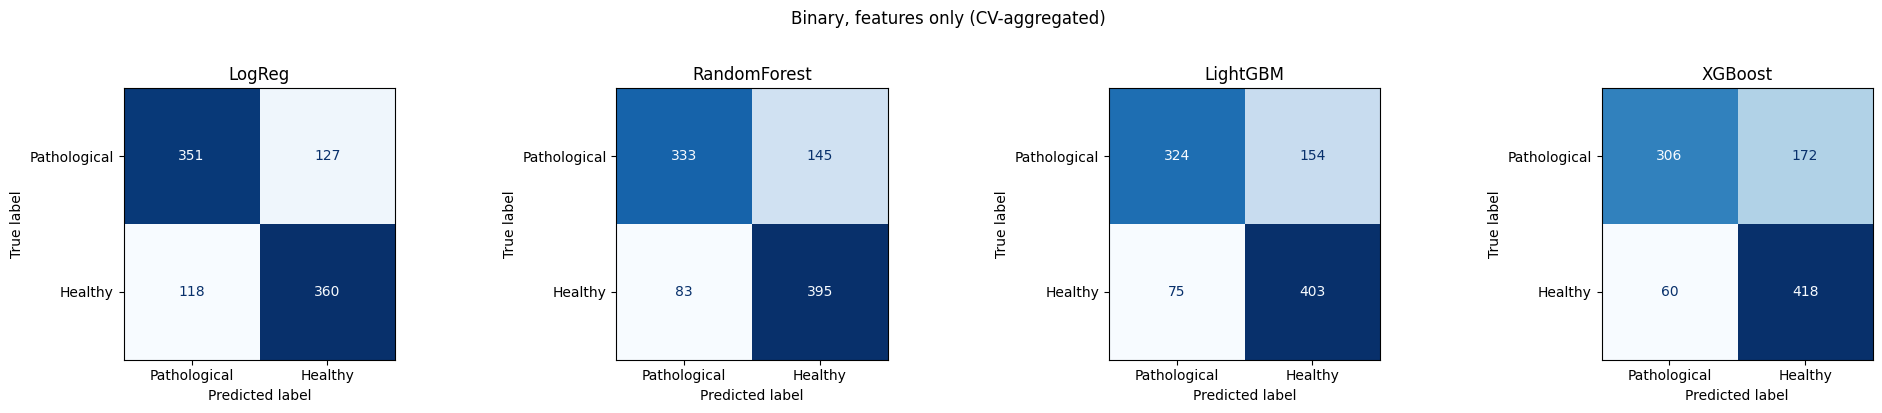

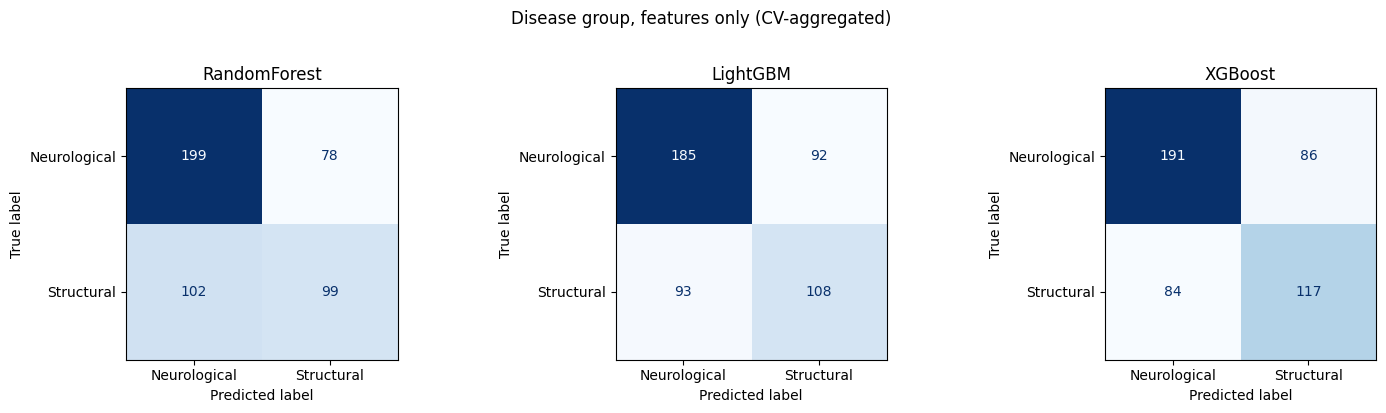

In [26]:
fig, axes = plt.subplots(1, len(binary_models), figsize=(5 * len(binary_models), 4))
for ax, name in zip(axes, binary_models):
    yt, yp = bin_preds[('Main set (v7 protocol)', 'features only', name)]
    ConfusionMatrixDisplay(confusion_matrix(yt, yp, labels=[0, 1]),
                           display_labels=['Pathological', 'Healthy']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
fig.suptitle('Binary, features only (CV-aggregated)', y=1.02); fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(multi_models), figsize=(5 * len(multi_models), 4))
for ax, name in zip(axes, multi_models):
    yt, yp = multi_preds[('Main set (v7 protocol)', 'features only', name)]
    labs = sorted(set(yt))
    ConfusionMatrixDisplay(confusion_matrix(yt, yp, labels=labs), display_labels=labs).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
fig.suptitle('Disease group, features only (CV-aggregated)', y=1.02); fig.tight_layout(); plt.show()

## 13 — Feature importances (main set, trained on all data, for illustration)

With age + sex included, expect `age` near the top for the binary task — that is the confound, shown directly.

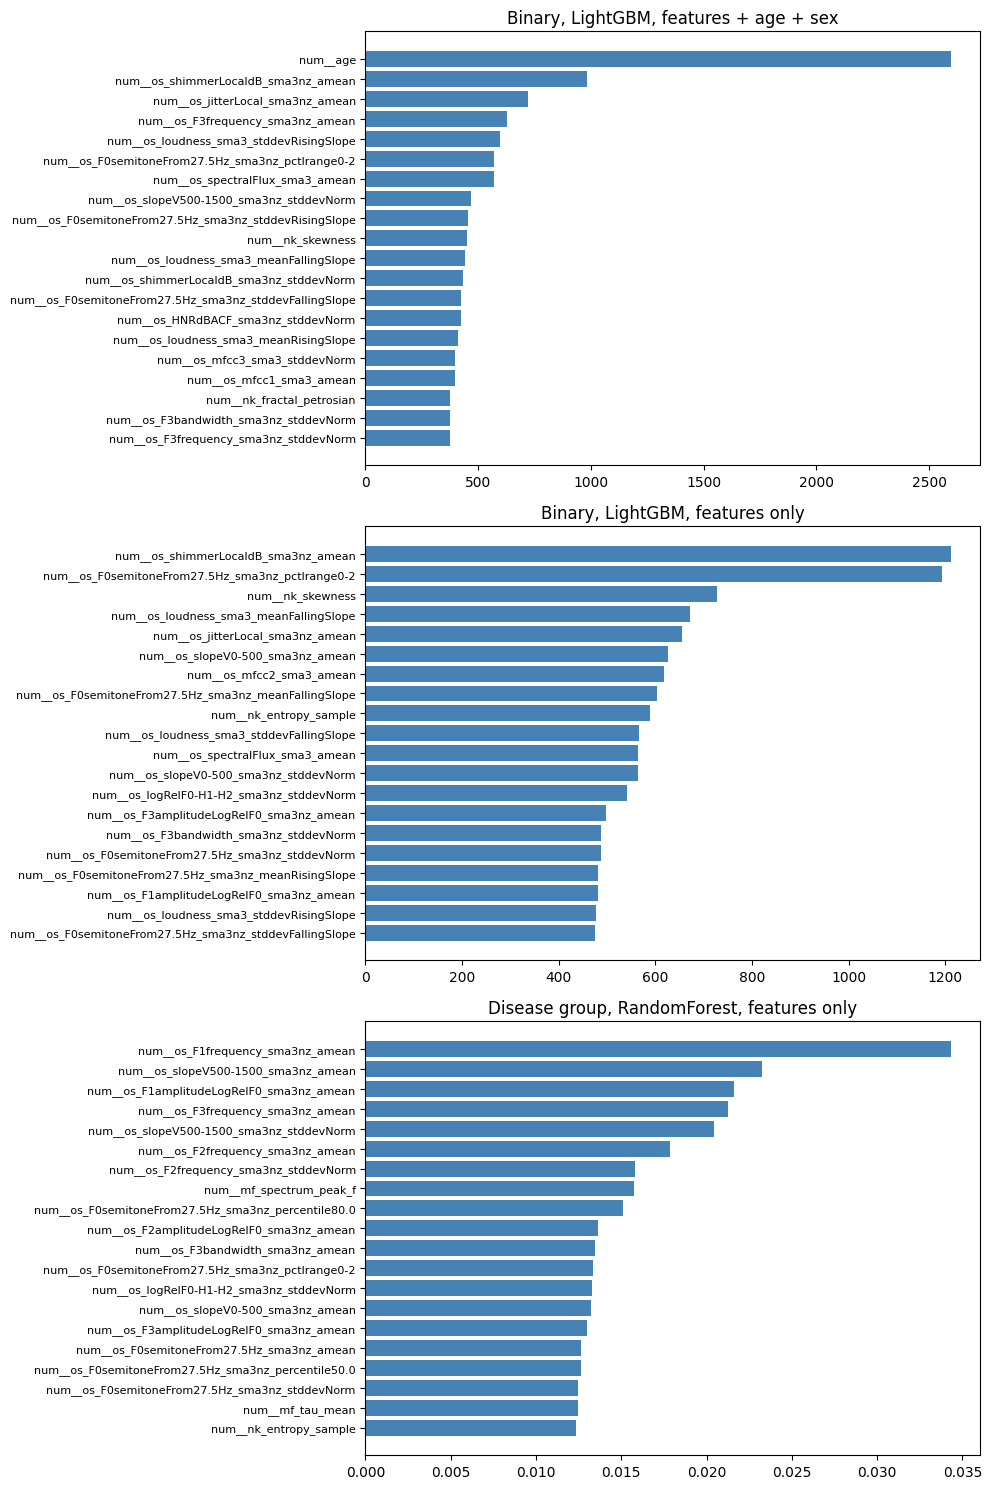

In [27]:
def importances(model, data, y, fs, sw=None):
    num, cat = FEATURE_SETS[fs]
    tp, lp = build_preprocessors(num, cat)
    pipe = make_pipe(model, tp, lp)
    pipe.fit(data[num + cat], y, **({'model__sample_weight': sw} if sw is not None else {}))
    return pd.Series(pipe.named_steps['model'].feature_importances_,
                     index=pipe.named_steps['prep'].get_feature_names_out()).sort_values(ascending=False)

le = LabelEncoder(); y_multi_enc = le.fit_transform(patho_main['target_label'])
panels = [
    ('Binary, LightGBM, features + age + sex', importances(binary_models['LightGBM'], df, df['is_healthy'].astype(int), 'features + age + sex')),
    ('Binary, LightGBM, features only',        importances(binary_models['LightGBM'], df, df['is_healthy'].astype(int), 'features only')),
    ('Disease group, RandomForest, features only',
     importances(multi_models['RandomForest'], patho_main, y_multi_enc, 'features only', sample_weights(y_multi_enc))),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(10, 5 * len(panels)))
for ax, (title, imp) in zip(axes, panels):
    top = imp.head(20)[::-1]
    ax.barh(range(len(top)), top.values, color='steelblue')
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(title)
    imp.to_csv(OUT_DIR / f"importances_{re.sub(r'[^a-z0-9]+', '_', title.lower())}.csv")
fig.tight_layout(); plt.show()

## 13b — Per-disease detection (each disease vs healthy)

Replaces `model_training_per_disease.ipynb`, which ran 2-fold CV for every disease and always included age + sex.
For each SVD pathology with at least `MIN_DISEASE_SAMPLES` a_n samples:

* **Unmatched** (as in the submitted table): the disease vs an equal-size random healthy sample (seed 42), with and without age + sex.
* **Age × sex matched**: the disease vs nearest-neighbour matched healthy samples (same sex, ±2 years), features only;
  reported only when at least `MIN_MATCHED_PAIRS` pairs are found.

Pool: all a_n samples after removing speakers with both healthy and pathological recordings.

In [28]:
DISEASE_EN = {
    'Morbus Parkinson': "Parkinson's disease", 'Phonationsknötchen': 'Vocal fold nodules',
    'Reinke Ödem': "Reinke's edema", 'Rekurrensparese': 'Recurrent laryngeal nerve paralysis',
    'Spasmodische Dysphonie': 'Spasmodic dysphonia', 'Stimmlippenpolyp': 'Vocal fold polyp',
    'Hyperfunktionelle Dysphonie': 'Hyperfunctional dysphonia', 'Funktionelle Dysphonie': 'Functional dysphonia',
    'Psychogene Dysphonie': 'Psychogenic dysphonia', 'Hypotone Dysphonie': 'Hypotonic dysphonia', 'Laryngitis': 'Laryngitis',
}
DISEASE_EN = {nfc(k): v for k, v in DISEASE_EN.items()}

pd_rows, pd_info = [], []
for disease_de, n in all_patho_pool['pathology_de'].value_counts().items():
    name = DISEASE_EN.get(disease_de, disease_de)
    cases = all_patho_pool[all_patho_pool['pathology_de'] == disease_de]
    if n < MIN_DISEASE_SAMPLES:
        pd_info.append({'disease': name, 'n_disease': n, 'note': f'skipped (< {MIN_DISEASE_SAMPLES} samples)'})
        continue
    unmatched = pd.concat([cases, healthy_pool_all.sample(n=min(n, len(healthy_pool_all)), random_state=RANDOM_SEED)])
    matched = nn_match(cases, healthy_pool_all)
    n_pairs = len(matched) // 2
    runs = [('unmatched', unmatched, 'features + age + sex'), ('unmatched', unmatched, 'features only')]
    if n_pairs >= MIN_MATCHED_PAIRS:
        runs.append(('age x sex matched', matched, 'features only'))
    pd_info.append({'disease': name, 'n_disease': n, 'matched_pairs': n_pairs,
                    'age_disease': cases.age.mean(), 'age_healthy_unmatched': unmatched[unmatched.is_healthy.astype(bool)].age.mean(),
                    'note': '' if n_pairs >= MIN_MATCHED_PAIRS else f'matched result not reported (< {MIN_MATCHED_PAIRS} pairs)'})
    for setting, data, fs in runs:
        num, cat = FEATURE_SETS[fs]
        tp, lp = build_preprocessors(num, cat)
        y = data['is_healthy'].astype(int); groups = data['speaker_id'].astype(str)
        for mname, model in binary_models.items():
            rows, _, _ = cv_binary(model, data[num + cat], y, groups, tp, lp)
            pd_rows += [{'disease': name, 'setting': setting, 'features': fs, 'model': mname,
                         'n_samples': len(data), **r} for r in rows]
    print(f'done: {name} (n={n}, matched pairs={n_pairs})')

pd_info = pd.DataFrame(pd_info).round(1)
display(pd_info)
per_disease_folds = pd.DataFrame(pd_rows)
per_disease_sum = summarise(per_disease_folds, ['disease', 'setting', 'features', 'model', 'n_samples'])

best_pd = (per_disease_sum.sort_values('f1_macro_mean', ascending=False)
           .drop_duplicates(['disease', 'setting', 'features']))
best_pd['cell'] = (best_pd.f1_macro_mean.map('{:.3f}'.format) + ' ± ' + best_pd.f1_macro_sd.map('{:.3f}'.format)
                   + ' (' + best_pd.model + ')')
best_pd['column'] = best_pd.setting + ' | ' + best_pd.features
per_disease_table = best_pd.pivot(index='disease', columns='column', values='cell')
per_disease_table = per_disease_table.join(pd_info.set_index('disease')[['n_disease', 'matched_pairs']])
print('Per-disease macro F1, best model (mean ± SD over 5 folds):')
display(per_disease_table.sort_values('n_disease', ascending=False))

done: Recurrent laryngeal nerve paralysis (n=212, matched pairs=85)
done: Hyperfunctional dysphonia (n=205, matched pairs=132)
done: Laryngitis (n=140, matched pairs=99)
done: Functional dysphonia (n=107, matched pairs=85)
done: Psychogenic dysphonia (n=88, matched pairs=59)
done: Reinke's edema (n=67, matched pairs=45)
done: Spasmodic dysphonia (n=64, matched pairs=25)
done: Vocal fold polyp (n=44, matched pairs=36)
done: Vocal fold nodules (n=17, matched pairs=16)


,disease,n_disease,matched_pairs,age_disease,age_healthy_unmatched,note
0,Recurrent laryngeal nerve paralysis,212,85.0,57.6,29.4,
1,Hyperfunctional dysphonia,205,132.0,44.1,29.4,
2,Laryngitis,140,99.0,50.6,29.4,
3,Functional dysphonia,107,85.0,48.6,29.3,
4,Psychogenic dysphonia,88,59.0,49.7,29.9,
5,Reinke's edema,67,45.0,54.0,29.1,
6,Spasmodic dysphonia,64,25.0,54.7,29.2,
7,Vocal fold polyp,44,36.0,53.8,30.6,
8,Vocal fold nodules,17,16.0,34.4,35.5,matched result not reported (< 20 pairs)
9,Hypotonic dysphonia,5,NaN,NaN,NaN,skipped (< 10 samples)


Per-disease macro F1, best model (mean ± SD over 5 folds):


,age x sex matched | features only,unmatched | features + age + sex,unmatched | features only,n_disease,matched_pairs
disease,,,,,
Recurrent laryngeal nerve paralysis,0.696 ± 0.085 (LightGBM),0.882 ± 0.028 (XGBoost),0.786 ± 0.032 (LightGBM),212,85.0
Hyperfunctional dysphonia,0.602 ± 0.080 (LightGBM),0.753 ± 0.067 (LightGBM),0.657 ± 0.030 (LogReg),205,132.0
Laryngitis,0.601 ± 0.119 (RandomForest),0.772 ± 0.040 (XGBoost),0.683 ± 0.065 (XGBoost),140,99.0
Functional dysphonia,0.562 ± 0.087 (LogReg),0.766 ± 0.044 (LightGBM),0.610 ± 0.052 (LogReg),107,85.0
Psychogenic dysphonia,0.633 ± 0.116 (LogReg),0.806 ± 0.072 (XGBoost),0.714 ± 0.140 (XGBoost),88,59.0
Reinke's edema,0.742 ± 0.051 (RandomForest),0.828 ± 0.062 (LightGBM),0.777 ± 0.056 (RandomForest),67,45.0
Spasmodic dysphonia,0.713 ± 0.227 (RandomForest),0.699 ± 0.184 (LightGBM),0.663 ± 0.226 (LogReg),64,25.0
Vocal fold polyp,0.544 ± 0.164 (LightGBM),0.754 ± 0.141 (LightGBM),0.683 ± 0.068 (RandomForest),44,36.0
Vocal fold nodules,NaN,0.683 ± 0.169 (XGBoost),0.683 ± 0.169 (XGBoost),17,16.0


## 14 — Export and headline numbers

In [29]:
bin_folds.to_csv(OUT_DIR / 'binary_folds.csv', index=False)
multi_folds.to_csv(OUT_DIR / 'multiclass_folds.csv', index=False)
bin_sum.to_csv(OUT_DIR / 'binary_summary.csv', index=False)
multi_sum.to_csv(OUT_DIR / 'multiclass_summary.csv', index=False)
per_disease_folds.to_csv(OUT_DIR / 'per_disease_folds.csv', index=False)
per_disease_sum.to_csv(OUT_DIR / 'per_disease_summary.csv', index=False)
per_disease_table.to_csv(OUT_DIR / 'per_disease_table.csv')
pd_info.to_csv(OUT_DIR / 'per_disease_info.csv', index=False)
protocol_df.to_csv(OUT_DIR / 'protocol_log.csv', index=False)
for name, x in [('binary_matched_6_groups', bin_matched_6), ('binary_matched_all_pathologies', bin_matched_all),
                ('disease_group_matched', multi_matched)]:
    x[['sample_key', 'speaker_id', 'pathology_de', 'target_label', 'age', 'sex']].to_csv(OUT_DIR / f'{name}_samples.csv', index=False)
print('Saved to', OUT_DIR.resolve())

def line(s, setting, fs):
    r = s[(s.setting == setting) & (s.features == fs)].sort_values('f1_macro_mean', ascending=False).iloc[0]
    return (f'{setting:38s} {fs:22s} n={int(r.n_samples):4d}  F1 {r.f1_macro_mean:.3f} ± {r.f1_macro_sd:.3f} '
            f'[{r.f1_macro_ci_lo:.3f}, {r.f1_macro_ci_hi:.3f}]  bal.acc {r.balanced_accuracy_mean:.3f}  ({r.model})')

print('\nBINARY (best model)')
for setting, _, fsets in BINARY_SETTINGS:
    for fs in fsets:
        print(' ', line(bin_sum, setting, fs))
print('\nDISEASE GROUP (best model)')
for setting, _, fsets in MULTI_SETTINGS:
    for fs in fsets:
        print(' ', line(multi_sum, setting, fs))

Saved to G:\Projects\multifractal-speech-analysis\results\main_v8

BINARY (best model)
  Main set (v7 protocol)                 features + age + sex   n= 956  F1 0.882 ± 0.025 [0.851, 0.912]  bal.acc 0.882  (XGBoost)
  Main set (v7 protocol)                 features only          n= 956  F1 0.760 ± 0.042 [0.709, 0.812]  bal.acc 0.762  (RandomForest)
  Main set (v7 protocol)                 age + sex only         n= 956  F1 0.846 ± 0.017 [0.824, 0.868]  bal.acc 0.846  (XGBoost)
  Age x sex matched, 6 disease groups    features only          n= 316  F1 0.679 ± 0.044 [0.625, 0.734]  bal.acc 0.683  (LightGBM)
  Age x sex matched, 6 disease groups    age + sex only         n= 316  F1 0.386 ± 0.061 [0.310, 0.462]  bal.acc 0.447  (LogReg)
  Age x sex matched, all pathologies     features only          n= 460  F1 0.626 ± 0.061 [0.549, 0.702]  bal.acc 0.630  (LogReg)
  Age x sex matched, all pathologies     age + sex only         n= 460  F1 0.440 ± 0.055 [0.372, 0.508]  bal.acc 0.470  (LogReg)
